# Лабораторная работа №1

In [24]:
# Иморты
from AutomationML.factory import ModelFactory
from AutomationML.pipeline import PipelineBuilder
from AutomationML.search import SearchFactory, run_optuna_manual
from sklearn.metrics import mean_absolute_error, r2_score
from params import PARAM_SPACES
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from AutomationML.errors import OptionalDependencyError
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [11]:
california = fetch_california_housing(as_frame=True)

X = california['data']
y = california['target']
X.shape, y.shape

((20640, 8), (20640,))

In [12]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

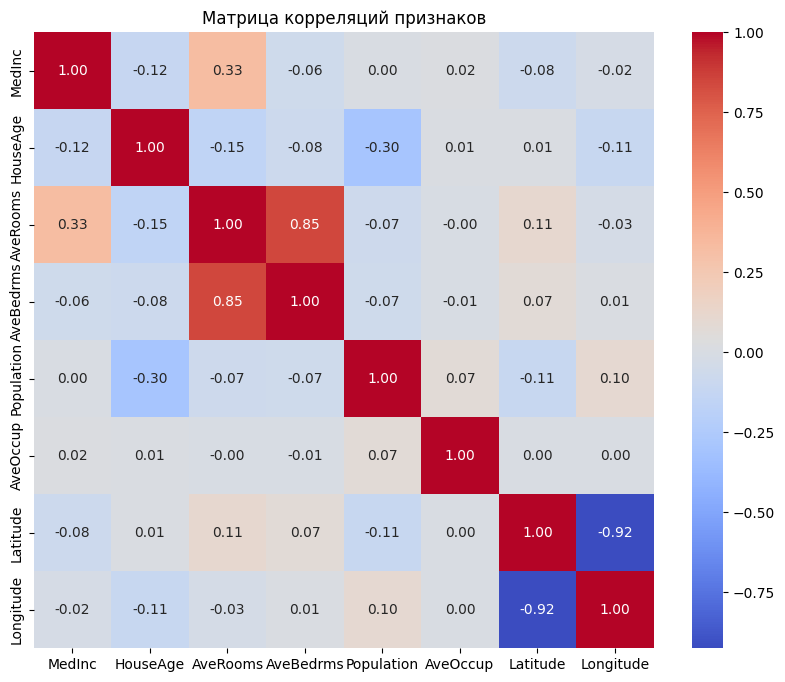

In [26]:
X_df = pd.DataFrame(X)

corr = X_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляций признаков")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18576, 8), (2064, 8), (18576,), (2064,))

In [14]:
models_factory = ModelFactory(random_state=42)
search_factory = SearchFactory(random_state=42)
models_factory.list_models('reg')

['BaggingRegressor',
 'CatBoostRegressor',
 'DecisionTreeRegressor',
 'GradientBoostingRegressor',
 'KNeighborsRegressor',
 'LGBMRegressor',
 'Lasso',
 'LinearRegression',
 'PolynomialRegression',
 'RandomForestRegressor',
 'Ridge',
 'SVR',
 'StackingRegressor',
 'XGBRegressor']

In [15]:
models_names = ['LinearRegression', 'RandomForestRegressor', 'GradientBoostingRegressor', 'XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor']

In [16]:
def prefix_space(space: dict, prefix: str = "model__") -> dict:
    """Добаляет префикс шага пайплайна к ключам (для шага 'model')."""
    out = {}
    for k, v in space.items():
        out[k if k.startswith(prefix) else f"{prefix}{k}"] = v
    return out

In [17]:
results = []

for name in models_names:
    print(f"Сейчас: {name}")

    # scaler включаем только там, где он действительно нужен (линейные/методы, чувствительные к масштабу)
    need_scaler = name in {"LinearRegression"}
    try:
        pipe = PipelineBuilder(
            model=models_factory.create(name, expected_task="reg"),
            scaler=True if need_scaler else None,
            sample=False,
            random_state=42,
            n_jobs=-1,
        ).build()
    except OptionalDependencyError as e:
        print(f"Пропускаю {name}: {e}")
        continue

    param_space = prefix_space(PARAM_SPACES[name])

    search = search_factory.create(
        method="optuna",
        estimator=pipe,
        estimator_path=None,
        param_space=param_space,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_trials=40,
        n_jobs=-1,
    )

    if hasattr(search, "fit"):
        search.fit(X_train, y_train)
        best = search.best_estimator_
        cv_score = float(search.best_score_)
    else:
        mode, cfg = search

        def pipeline_factory(**kwargs):
            p = clone(pipe)
            p.set_params(**kwargs)
            return p

        study = run_optuna_manual(
            estimator_class=pipeline_factory,
            grid=param_space,
            X_train=X_train, y_train=y_train,
            scoring=cfg["scoring"], cv=cfg["cv"],
            n_trials=cfg["n_trials"],
            study_direction=cfg.get("study_direction", "maximize"),
            sampler=cfg.get("sampler"), pruner=cfg.get("pruner"),
            fit_params=cfg.get("fit_params"), fixed_params=cfg.get("fixed_params"),
            timeout=cfg.get("timeout"), callbacks=cfg.get("callbacks"),
        )
        best = pipeline_factory(**study.best_trial.params).fit(X_train, y_train)
        cv_score = float(study.best_value)

    # оценка на тесте
    y_pred = best.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"CV(mae) = {cv_score:.5f}")
    print(f"Test: MAE = {mae:.5f}, R2 = {r2:.5f}")

    results.append({"model": name, "cv_mae": -cv_score if cv_score < 0 else cv_score, "test_mae": mae, "test_r2": r2, "estimator": best})


results_sorted = sorted(results, key=lambda x: x["test_r2"], reverse=True)
top = results_sorted[0]
print("Лучшая модель:")
print(f"{top['model']}: R2={top['test_r2']:.5f}, MAE={top['test_mae']:.5f}")
best_model = top["estimator"]

c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(
[I 2025-09-20 08:33:09,260] A new study created in memory with name: no-name-d533ac83-8e78-488c-8a11-8790f71d6c12


Сейчас: LinearRegression


[I 2025-09-20 08:33:09,722] Trial 2 finished with value: -2.071898177432917 and parameters: {'model__fit_intercept': False, 'model__positive': False}. Best is trial 2 with value: -2.071898177432917.
[I 2025-09-20 08:33:09,728] Trial 3 finished with value: -0.6006019550921882 and parameters: {'model__fit_intercept': True, 'model__positive': True}. Best is trial 3 with value: -0.6006019550921882.
[I 2025-09-20 08:33:09,774] Trial 0 finished with value: -2.071898177432917 and parameters: {'model__fit_intercept': False, 'model__positive': False}. Best is trial 3 with value: -0.6006019550921882.
[I 2025-09-20 08:33:09,779] Trial 1 finished with value: -2.071898177432917 and parameters: {'model__fit_intercept': False, 'model__positive': False}. Best is trial 3 with value: -0.6006019550921882.
[I 2025-09-20 08:33:09,789] Trial 7 finished with value: -2.0710085502707987 and parameters: {'model__fit_intercept': False, 'model__positive': True}. Best is trial 3 with value: -0.6006019550921882.
[I

CV(mae) = -0.53023
Test: MAE = 0.54240, R2 = 0.58084
Сейчас: RandomForestRegressor


[I 2025-09-20 08:33:21,589] Trial 0 finished with value: -0.37133523785421413 and parameters: {'model__n_estimators': 50, 'model__max_depth': 19, 'model__min_samples_split': 15, 'model__min_samples_leaf': 19}. Best is trial 0 with value: -0.37133523785421413.
[I 2025-09-20 08:33:24,328] Trial 12 finished with value: -0.34252103702617437 and parameters: {'model__n_estimators': 50, 'model__max_depth': 24, 'model__min_samples_split': 6, 'model__min_samples_leaf': 5}. Best is trial 12 with value: -0.34252103702617437.
[I 2025-09-20 08:33:27,624] Trial 8 finished with value: -0.4243331326335535 and parameters: {'model__n_estimators': 100, 'model__max_depth': 7, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10}. Best is trial 12 with value: -0.34252103702617437.
[I 2025-09-20 08:33:28,301] Trial 6 finished with value: -0.35720638840576086 and parameters: {'model__n_estimators': 75, 'model__max_depth': 11, 'model__min_samples_split': 6, 'model__min_samples_leaf': 5}. Best is tria

CV(mae) = -0.33457
Test: MAE = 0.32263, R2 = 0.80989
Сейчас: GradientBoostingRegressor


[I 2025-09-20 08:35:54,436] Trial 12 finished with value: -0.389860034579363 and parameters: {'model__n_estimators': 50, 'model__learning_rate': 0.06221575917561101, 'model__max_depth': 5, 'model__min_samples_split': 20, 'model__min_samples_leaf': 3, 'model__subsample': 0.7536287295929194}. Best is trial 12 with value: -0.389860034579363.
[I 2025-09-20 08:35:55,312] Trial 10 finished with value: -0.7936861506447809 and parameters: {'model__n_estimators': 50, 'model__learning_rate': 0.004188153012984983, 'model__max_depth': 7, 'model__min_samples_split': 8, 'model__min_samples_leaf': 19, 'model__subsample': 0.6239829470845981}. Best is trial 12 with value: -0.389860034579363.
[I 2025-09-20 08:36:01,701] Trial 7 finished with value: -0.36858918527475004 and parameters: {'model__n_estimators': 200, 'model__learning_rate': 0.13449176327398554, 'model__max_depth': 2, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__subsample': 0.7173123389872875}. Best is trial 7 with 

CV(mae) = -0.30093
Test: MAE = 0.28782, R2 = 0.84815
Сейчас: XGBRegressor


[I 2025-09-20 08:40:30,799] Trial 12 finished with value: -0.8216203710685693 and parameters: {'model__n_estimators': 200, 'model__learning_rate': 0.0012847000315581365, 'model__max_depth': 4, 'model__subsample': 0.6585474644590357, 'model__colsample_bytree': 0.5394720028965623, 'model__reg_alpha': 6.396651463515301e-06, 'model__reg_lambda': 0.004948992895644296, 'model__min_child_weight': 0.022855177155364528}. Best is trial 12 with value: -0.8216203710685693.
[I 2025-09-20 08:40:30,879] Trial 9 finished with value: -0.7503304424079896 and parameters: {'model__n_estimators': 150, 'model__learning_rate': 0.0025161172970830374, 'model__max_depth': 5, 'model__subsample': 0.909518065630563, 'model__colsample_bytree': 0.7702755080786852, 'model__reg_alpha': 5.951571586505973e-08, 'model__reg_lambda': 1.4426096976077986e-05, 'model__min_child_weight': 0.020368754136381673}. Best is trial 9 with value: -0.7503304424079896.
[I 2025-09-20 08:40:31,263] Trial 6 finished with value: -0.498681867

CV(mae) = -0.29093
Test: MAE = 0.27924, R2 = 0.85784
Сейчас: LGBMRegressor


[I 2025-09-20 08:42:08,149] Trial 1 finished with value: -0.7096225928208865 and parameters: {'model__n_estimators': 150, 'model__learning_rate': 0.004251199735744178, 'model__max_depth': 3, 'model__num_leaves': 20, 'model__subsample': 0.6323831251676576, 'model__colsample_bytree': 0.6947261461025844, 'model__min_child_samples': 5, 'model__reg_alpha': 6.982510982490904e-05, 'model__reg_lambda': 0.5907977813842866}. Best is trial 1 with value: -0.7096225928208865.
[I 2025-09-20 08:42:08,624] Trial 8 finished with value: -0.4632827711178369 and parameters: {'model__n_estimators': 100, 'model__learning_rate': 0.013957157851992372, 'model__max_depth': 8, 'model__num_leaves': 55, 'model__subsample': 0.5334322912520593, 'model__colsample_bytree': 0.8316722166027312, 'model__min_child_samples': 60, 'model__reg_alpha': 2.7201680338915843e-08, 'model__reg_lambda': 3.702712758410702e-08}. Best is trial 8 with value: -0.4632827711178369.
[I 2025-09-20 08:42:09,476] Trial 12 finished with value: -

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,001268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 18576, number of used features: 8
[LightGBM] [Info] Start training from score 2,068617


c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(
[I 2025-09-20 08:42:35,035] A new study created in memory with name: no-name-ee647db3-becd-4be0-9b10-3b4d044a03b5


CV(mae) = -0.28787
Test: MAE = 0.27824, R2 = 0.85894
Сейчас: CatBoostRegressor


[I 2025-09-20 08:42:43,793] Trial 0 finished with value: -0.7490450357681778 and parameters: {'model__iterations': 400, 'model__depth': 4, 'model__learning_rate': 0.0011091256027652016, 'model__l2_leaf_reg': 8.875965496914523, 'model__bagging_temperature': 0.3682349076381104, 'model__loss_function': 'RMSE'}. Best is trial 0 with value: -0.7490450357681778.
[I 2025-09-20 08:42:45,236] Trial 9 finished with value: -0.43009694680314287 and parameters: {'model__iterations': 400, 'model__depth': 5, 'model__learning_rate': 0.008153289473090517, 'model__l2_leaf_reg': 2.556108616461615, 'model__bagging_temperature': 0.9639353781888645, 'model__loss_function': 'MAE'}. Best is trial 9 with value: -0.43009694680314287.
[I 2025-09-20 08:42:45,360] Trial 13 finished with value: -0.3755944690761209 and parameters: {'model__iterations': 300, 'model__depth': 6, 'model__learning_rate': 0.018405236001736616, 'model__l2_leaf_reg': 9.854779514778205, 'model__bagging_temperature': 0.9744216885772846, 'mode

CV(mae) = -0.28577
Test: MAE = 0.27515, R2 = 0.86399
Лучшая модель:
CatBoostRegressor: R2=0.86399, MAE=0.27515


In [18]:
import joblib
joblib.dump(best_model, 'model.joblib')

['model.joblib']

In [20]:
best_model = joblib.load('model.joblib')
best_model

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False


MAE: 0.2751490353537825
R2: 0.8639862491252154


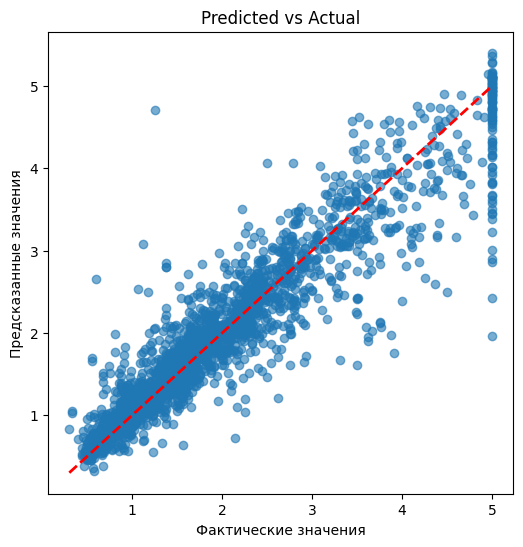

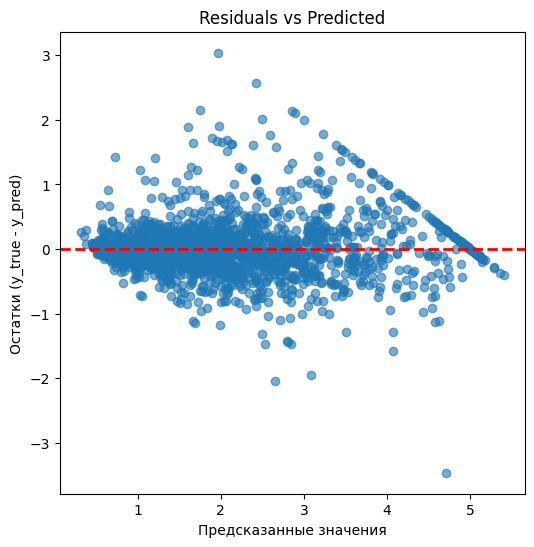

In [28]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}")
print(f"R2: {r2}")

residuals = y_test - y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Predicted vs Actual")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--", lw=2)
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки (y_true - y_pred)")
plt.title("Residuals vs Predicted")
plt.show()